In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset.kitti_dataset import KittiDataset
from src.preprocessing.bev import bev_projection
from src.geometry.boxes import create_box_corners_camera
from src.geometry.transforms import (
    rectified_camera_to_lidar,
    lidar_xy_to_bev
)

In [2]:
dataset = KittiDataset("../data/KITTI")

for idx in range(len(dataset)):

    candidate = dataset[idx]

    cars = [
        obj for obj in candidate["labels"]
        if obj["type"] == "Car"
    ]

    if cars:
        sample = candidate
        break

print("Found sample:", sample["id"])
print("Cars:", len(cars))

Found sample: 000001
Cars: 1


In [3]:
points = sample["points"]
labels = sample["labels"]
calib = sample["calib"]

bev = bev_projection(points)

cars = [
    obj for obj in labels
    if obj["type"] == "Car"
]

print("ID:", sample["id"])
print("Points:", points.shape)
print("BEV:", bev.shape)
print("Labels:", len(labels))
print("Cars:", len(cars))

ID: 000001
Points: (120268, 4)
BEV: (3, 350, 400)
Labels: 7
Cars: 1


In [4]:
car = cars[0]

corners_camera = create_box_corners_camera(
    car["dimensions"],
    car["location"],
    car["rotation_y"]
)

print(corners_camera.shape)
print(corners_camera)

(8, 3)
[[-15.59353107   2.39        56.64574515]
 [-17.46353048   2.39        56.64425602]
 [-17.46646893   2.39        60.33425485]
 [-15.59646952   2.39        60.33574398]
 [-15.59353107   0.72        56.64574515]
 [-17.46353048   0.72        56.64425602]
 [-17.46646893   0.72        60.33425485]
 [-15.59646952   0.72        60.33574398]]


In [5]:
corners_lidar = rectified_camera_to_lidar(
    corners_camera,
    calib["tr_velo_to_cam"],
    calib["r0_rect"]
)

print(corners_lidar.shape)
print(corners_lidar)

(8, 3)
[[ 5.69368671e+01  1.56229875e+01 -1.70527816e+00]
 [ 5.69349390e+01  1.74928824e+01 -1.68554003e+00]
 [ 6.06247355e+01  1.74962796e+01 -1.64694368e+00]
 [ 6.06266636e+01  1.56263847e+01 -1.66668181e+00]
 [ 5.69194166e+01  1.56053434e+01 -3.54625169e-02]
 [ 5.69174885e+01  1.74752382e+01 -1.57243828e-02]
 [ 6.06072850e+01  1.74786354e+01  2.28719617e-02]
 [ 6.06092131e+01  1.56087406e+01  3.13382761e-03]]


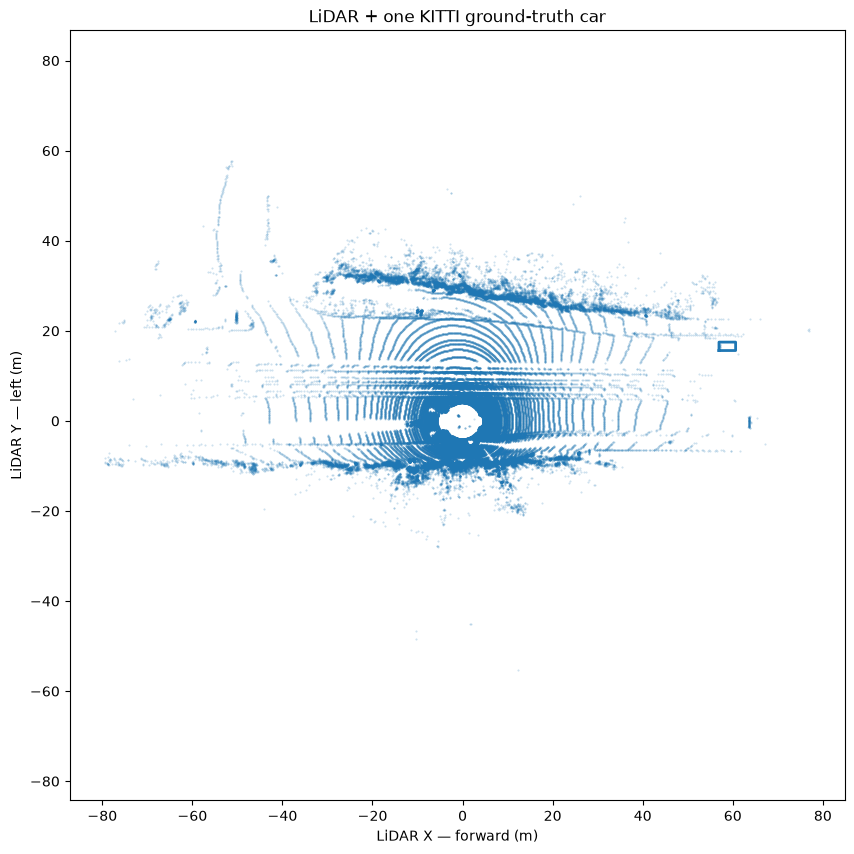

In [6]:
bottom_xy = corners_lidar[:4, :2]

bottom_closed = np.vstack([
    bottom_xy,
    bottom_xy[0]
])

plt.figure(figsize=(10, 10))

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=0.2,
    alpha=0.25
)

plt.plot(
    bottom_closed[:, 0],
    bottom_closed[:, 1],
    linewidth=2
)

plt.xlim(0, 70)
plt.ylim(-40, 40)

plt.xlabel("LiDAR X — forward (m)")
plt.ylabel("LiDAR Y — left (m)")
plt.title("LiDAR + one KITTI ground-truth car")
plt.axis("equal")

plt.show()

In [7]:
corners_bev = lidar_xy_to_bev(
    bottom_xy
)

print(corners_bev)

[[284.68433532 278.11493753]
 [284.67469494 287.4644118 ]
 [303.12367768 287.48139776]
 [303.13331806 278.13192348]]


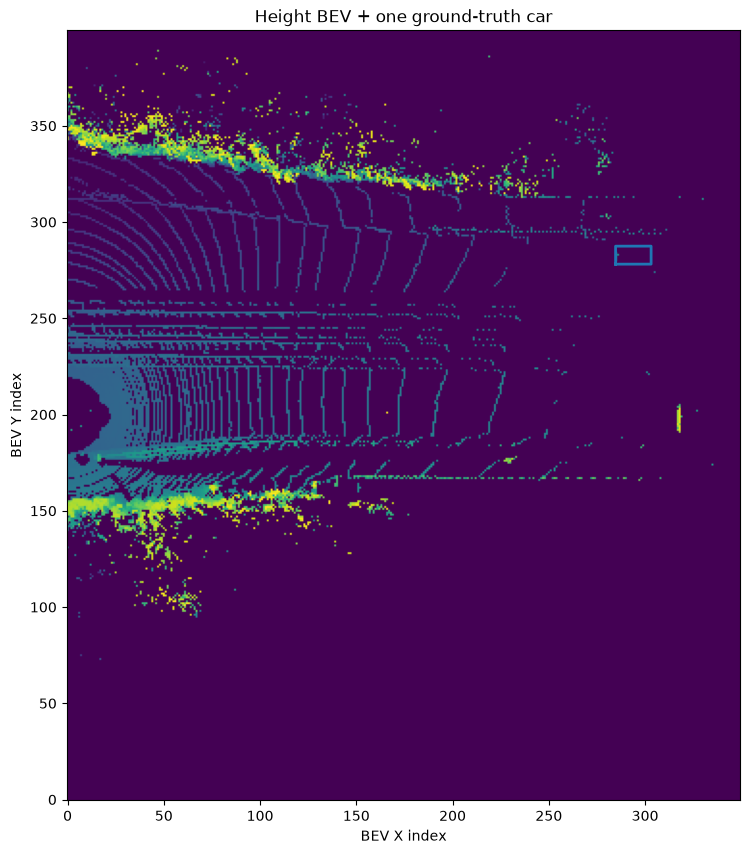

In [8]:
box_closed = np.vstack([
    corners_bev,
    corners_bev[0]
])

plt.figure(figsize=(10, 10))

plt.imshow(
    bev[0].T,
    origin="lower",
    aspect="equal"
)

plt.plot(
    box_closed[:, 0],
    box_closed[:, 1],
    linewidth=2
)

plt.xlabel("BEV X index")
plt.ylabel("BEV Y index")
plt.title("Height BEV + one ground-truth car")

plt.show()

In [13]:
bev_boxes = []

for obj in labels:

    if obj["type"] != "Car":
        continue

    corners_camera = create_box_corners_camera(
        obj["dimensions"],
        obj["location"],
        obj["rotation_y"]
    )

    corners_lidar = rectified_camera_to_lidar(
        corners_camera,
        calib["tr_velo_to_cam"],
        calib["r0_rect"]
    )

    bottom_xy = corners_lidar[:4, :2]

    center = bottom_xy.mean(axis=0)

    if not (
        0 <= center[0] < 70 and
        -40 <= center[1] < 40
    ):
        continue

    corners_bev = lidar_xy_to_bev(bottom_xy)

    bev_boxes.append(corners_bev)

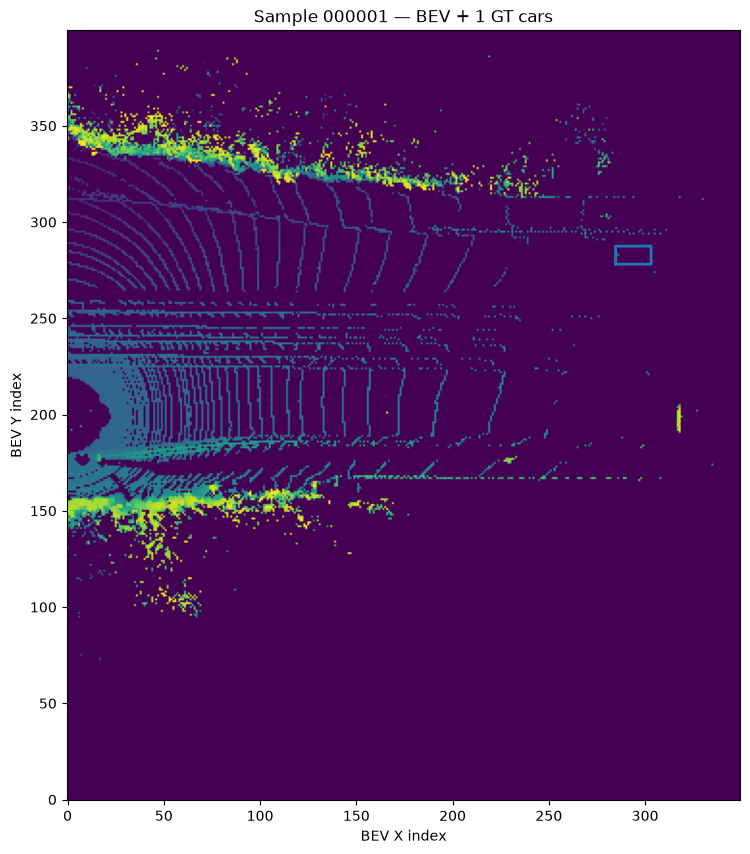

In [14]:
plt.figure(figsize=(10, 10))

plt.imshow(
    bev[0].T,
    origin="lower",
    aspect="equal"
)

for corners in bev_boxes:

    closed = np.vstack([
        corners,
        corners[0]
    ])

    plt.plot(
        closed[:, 0],
        closed[:, 1],
        linewidth=2
    )

plt.xlabel("BEV X index")
plt.ylabel("BEV Y index")

plt.title(
    f"Sample {sample['id']} — BEV + {len(bev_boxes)} GT cars"
)

plt.show()